# 1. 데이터 준비 & 머지 단계

In [34]:
import pandas as pd

# --------------------------------
# 1. 파일 경로 설정
# --------------------------------
path_birth = "출생등록_시군구코드_2023.csv"
path_obgyn = "지역별_산부인과_기관수_2023_SIGUNGU_CD포함.csv"
path_pp    = "시군구별_산후조리원_통계_2023_SIGUNGU_CD포함.csv"

# --------------------------------
# 2. CSV 불러오기
# --------------------------------
birth_raw = pd.read_csv(path_birth, encoding="utf-8-sig")
obgyn_raw = pd.read_csv(path_obgyn, encoding="utf-8-sig")
pp_raw    = pd.read_csv(path_pp,    encoding="utf-8-sig")

# --------------------------------
# 3. 출생등록 2023 정리
#    컬럼: ['시도명칭', '시군구명칭', '출생등록 수', '시군구코드']
# --------------------------------
birth_2023 = birth_raw.rename(columns={
    "시도명칭"  : "시도",
    "시군구명칭": "시군구",
    "출생등록 수": "출생등록수",
    "시군구코드": "SIGUNGU_CD"
}).copy()

birth_2023["출생등록수"] = (
    birth_2023["출생등록수"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype("int64")
)

birth_2023 = birth_2023[["SIGUNGU_CD", "시도", "시군구", "출생등록수"]]

# --------------------------------
# 4. 산부인과 2023 정리
#    컬럼: ['연도', '시도', '시군구', '산부인과', 'SIGUNGU_CD']
# --------------------------------
obgyn_2023 = obgyn_raw.copy()
obgyn_2023 = obgyn_2023[obgyn_2023["연도"] == 2023].copy()
obgyn_2023 = obgyn_2023[["SIGUNGU_CD", "산부인과"]]

# --------------------------------
# 5. 산후조리원 2023 정리
#    컬럼: ['년도', '시도', '시군구', '산후조리원수', '총병실수', 'SIGUNGU_CD']
# --------------------------------
pp_2023 = pp_raw.copy()
pp_2023 = pp_2023[pp_2023["년도"] == 2023].copy()
pp_2023 = pp_2023[["SIGUNGU_CD", "산후조리원수", "총병실수", "시군구"]]
pp_2023["총병실수"] = pp_2023["총병실수"].fillna(0).astype("int64")

# ======================================================
# 🔴 여기서부터 부천/창원 특수 전처리
#   - 부천: 세 구(원미/소사/오정)를 "부천시" 하나로
#   - 창원: 다섯 구(의창/성산/마산합포/마산회원/진해)를 "창원시" 하나로
# ======================================================

# 1) 부천시 - 이미 시 전체 값이 세 번 복제된 상태 → 하나만 남기기
bucheon_codes = [31051, 31052, 31053]

# (1-1) 출생: 부천 세 구 중 하나만 남기고 시군구명은 '부천시'로 통일
mask_bucheon_birth = birth_2023["SIGUNGU_CD"].isin(bucheon_codes)
bucheon_birth = birth_2023[mask_bucheon_birth]
if not bucheon_birth.empty:
    row = bucheon_birth.iloc[0].copy()
    row["시군구"] = "부천시"
    # 대표 코드 하나 선택 (여기서는 가장 작은 코드 사용)
    row["SIGUNGU_CD"] = bucheon_birth["SIGUNGU_CD"].min()
    birth_2023 = pd.concat(
        [birth_2023[~mask_bucheon_birth], row.to_frame().T],
        ignore_index=True
    )

# (1-2) 산부인과: 이미 시 전체 값(18)이 3번 복제된 상태 → 하나만 남기기
mask_bucheon_obgyn = obgyn_2023["SIGUNGU_CD"].isin(bucheon_codes)
bucheon_obgyn = obgyn_2023[mask_bucheon_obgyn]
if not bucheon_obgyn.empty:
    row = bucheon_obgyn.iloc[0].copy()
    row["SIGUNGU_CD"] = bucheon_obgyn["SIGUNGU_CD"].min()
    obgyn_2023 = pd.concat(
        [obgyn_2023[~mask_bucheon_obgyn], row.to_frame().T],
        ignore_index=True
    )

# (1-3) 산후조리원: 이미 시 전체 값(개소/병실)이 3번 복제된 상태 → 하나만 남기기
mask_bucheon_pp = pp_2023["SIGUNGU_CD"].isin(bucheon_codes)
bucheon_pp = pp_2023[mask_bucheon_pp]
if not bucheon_pp.empty:
    row = bucheon_pp.iloc[0].copy()
    row["시군구"] = "부천시"
    row["SIGUNGU_CD"] = bucheon_pp["SIGUNGU_CD"].min()
    pp_2023 = pd.concat(
        [pp_2023[~mask_bucheon_pp], row.to_frame().T],
        ignore_index=True
    )


# 2) 창원시
#    - 출생/산부인과: 구별 값 → 시 전체 합으로 묶기
#    - 산후조리원: 시 전체 값이 다섯 구에 복제 → 하나만 남기기
changwon_codes = [38111, 38112, 38113, 38114, 38115]

# (2-1) 출생: 다섯 구 출생수를 합쳐서 "창원시" 한 행으로
mask_cw_birth = birth_2023["SIGUNGU_CD"].isin(changwon_codes)
cw_birth = birth_2023[mask_cw_birth]
if not cw_birth.empty:
    row = cw_birth.iloc[0].copy()
    row["시군구"] = "창원시"
    row["출생등록수"] = int(cw_birth["출생등록수"].sum())
    row["SIGUNGU_CD"] = cw_birth["SIGUNGU_CD"].min()
    birth_2023 = pd.concat(
        [birth_2023[~mask_cw_birth], row.to_frame().T],
        ignore_index=True
    )

# (2-2) 산부인과: 다섯 구 산부인과 수를 합쳐서 하나로
mask_cw_obgyn = obgyn_2023["SIGUNGU_CD"].isin(changwon_codes)
cw_obgyn = obgyn_2023[mask_cw_obgyn]
if not cw_obgyn.empty:
    row = cw_obgyn.iloc[0].copy()
    row["산부인과"] = int(cw_obgyn["산부인과"].sum())
    row["SIGUNGU_CD"] = cw_obgyn["SIGUNGU_CD"].min()
    obgyn_2023 = pd.concat(
        [obgyn_2023[~mask_cw_obgyn], row.to_frame().T],
        ignore_index=True
    )

# (2-3) 산후조리원: 이미 시 전체 값이 다섯 구에 복제된 상태 → 하나만 남기기
mask_cw_pp = pp_2023["SIGUNGU_CD"].isin(changwon_codes)
cw_pp = pp_2023[mask_cw_pp]
if not cw_pp.empty:
    row = cw_pp.iloc[0].copy()
    row["시군구"] = "창원시"
    row["SIGUNGU_CD"] = cw_pp["SIGUNGU_CD"].min()
    pp_2023 = pd.concat(
        [pp_2023[~mask_cw_pp], row.to_frame().T],
        ignore_index=True
    )

# --------------------------------
# 6. 세 데이터 시군구 코드 기준 병합
# --------------------------------
df_2023 = (
    birth_2023
    .merge(obgyn_2023, on="SIGUNGU_CD", how="left")
    .merge(pp_2023[["SIGUNGU_CD", "산후조리원수", "총병실수"]], on="SIGUNGU_CD", how="left")
)

# 시설 정보 없는 시군구는 0으로 처리
for col in ["산부인과", "산후조리원수", "총병실수"]:
    df_2023[col] = df_2023[col].fillna(0).astype("int64")

# 보기 좋게 정렬
df_2023 = df_2023.sort_values(["시도", "시군구"]).reset_index(drop=True)


C:\Users\h4624\AppData\Local\Temp\ipykernel_38324\1987266596.py:153: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_2023[col] = df_2023[col].fillna(0).astype("int64")
C:\Users\h4624\AppData\Local\Temp\ipykernel_38324\1987266596.py:153: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_2023[col] = df_2023[col].fillna(0).astype("int64")


# 2. "출생 대비 분만 인프라" 지표 만들기

In [ ]:
import numpy as np

# ------------------------------------------------
# 1. 작업용 복사본 생성
# ------------------------------------------------
df = df_2023.copy()

# 2. 출생 1,000명당 인프라 지표 계산
df["출생수_천명"] = df["출생등록수"] / 1000

mask_nonzero = df["출생등록수"] > 0

df["obgyn_per_1000"] = np.where(
    mask_nonzero,
    df["산부인과"] / df["출생수_천명"],
    np.nan
)

df["ppcenter_per_1000"] = np.where(
    mask_nonzero,
    df["산후조리원수"] / df["출생수_천명"],
    np.nan
)

df["ppbeds_per_1000"] = np.where(
    mask_nonzero,
    df["총병실수"] / df["출생수_천명"],
    np.nan
)

# ------------------------------------------------
# 3. 각 지표 표준화(z-score) 후 종합 인프라 지수 계산
# ------------------------------------------------
base_cols = ["obgyn_per_1000", "ppcenter_per_1000", "ppbeds_per_1000"]

for col in base_cols:
    mean_val = df[col].mean(skipna=True)
    std_val  = df[col].std(skipna=True, ddof=0)

    z_col = f"z_{col}"
    if std_val > 0:
        df[z_col] = (df[col] - mean_val) / std_val
    else:
        # 모든 값이 같아서 표준편차가 0인 경우
        df[z_col] = 0.0

# 종합 인프라 지수: 세 개 z-score의 단순 평균
z_cols = [f"z_{c}" for c in base_cols]
df["infra_index"] = df[z_cols].mean(axis=1)

# ------------------------------------------------
# 4. 결과 확인
# ------------------------------------------------
print(df[[
    "시도", "시군구", "출생등록수",
    "obgyn_per_1000", "ppcenter_per_1000", "ppbeds_per_1000",
"infra_index"
]].head())

# 필요하다면 df를 다시 df_2023에 덮어쓰기
df_2023 = df


        시도  시군구 출생등록수 obgyn_per_1000 ppcenter_per_1000 ppbeds_per_1000  \
0  강원특별자치도  강릉시   394      20.304569          7.614213     4670.050761   
1  강원특별자치도  고성군    28            0.0               0.0             0.0   
2  강원특별자치도  동해시   177      11.299435         11.299435     5310.734463   
3  강원특별자치도  삼척시   129       7.751938          7.751938     1395.348837   
4  강원특별자치도  속초시   135       29.62963               0.0             0.0   

  infra_index  
0    2.811921  
1   -0.802135  
2    2.889587  
3     1.20699  
4    1.234248  


# 3. 대도시권 vs 비대도시권 그룹 변수 만들기

In [36]:
# -------------------------------------------
# 대도시권 vs 비대도시권 그룹 변수 만들기
# -------------------------------------------

df = df_2023.copy()

# 1. 대도시권에 포함할 시도 목록 정의
metro_sido = [
    "서울특별시",
    "부산광역시",
    "대구광역시",
    "인천광역시",
    "광주광역시",
    "대전광역시",
    "울산광역시",
    "세종특별자치시",
    "경기도",
]

# 2. is_metro (1=대도시권, 0=비대도시권)
df["is_metro"] = df["시도"].isin(metro_sido).astype(int)

# 3. 사람이 보기 좋은 그룹 이름(optional)
df["metro_group"] = df["is_metro"].map({1: "대도시권", 0: "비대도시권"})

# 4. 확인
print(df[["시도", "시군구", "is_metro", "metro_group"]].head(20))

# 이후 분석에서 계속 쓸 수 있도록 덮어쓰기
df_2023 = df

         시도      시군구  is_metro metro_group
0   강원특별자치도      강릉시         0       비대도시권
1   강원특별자치도      고성군         0       비대도시권
2   강원특별자치도      동해시         0       비대도시권
3   강원특별자치도      삼척시         0       비대도시권
4   강원특별자치도      속초시         0       비대도시권
5   강원특별자치도      양구군         0       비대도시권
6   강원특별자치도      양양군         0       비대도시권
7   강원특별자치도      영월군         0       비대도시권
8   강원특별자치도      원주시         0       비대도시권
9   강원특별자치도      인제군         0       비대도시권
10  강원특별자치도      정선군         0       비대도시권
11  강원특별자치도      철원군         0       비대도시권
12  강원특별자치도      춘천시         0       비대도시권
13  강원특별자치도      태백시         0       비대도시권
14  강원특별자치도      평창군         0       비대도시권
15  강원특별자치도      홍천군         0       비대도시권
16  강원특별자치도      화천군         0       비대도시권
17  강원특별자치도      횡성군         0       비대도시권
18      경기도      가평군         1        대도시권
19      경기도  고양시 덕양구         1        대도시권


# 4. 메인 가설검정: 평균 인프라 지수 차이
## 4-1. EDA 한 번 체크

▶ 대도시권 / 비대도시권별 infra_index 요약 통계
             count      mean       std       min    median       max
metro_group                                                         
대도시권           118  0.214409  0.792177 -0.802135  0.103891  5.410778
비대도시권          128 -0.197658  0.735147 -0.802135 -0.301269  2.889587



<Figure size 600x500 with 0 Axes>

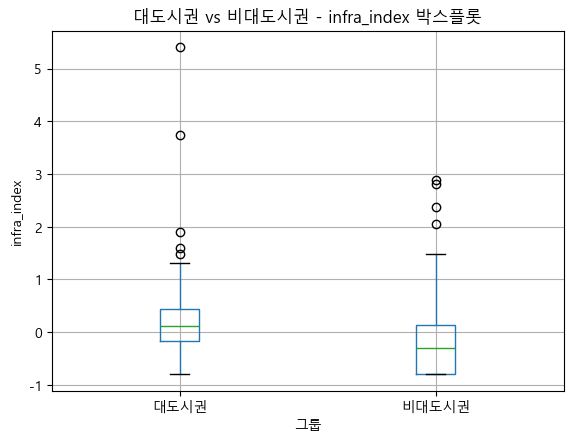

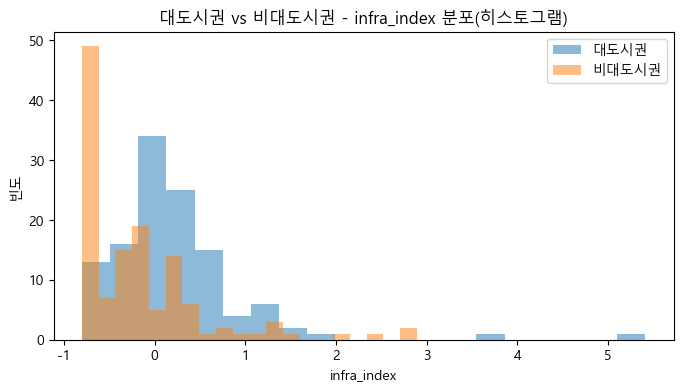

In [37]:
import matplotlib.pyplot as plt

# 한글 깨짐 방지 (윈도우 기준, 필요 없으면 주석 처리)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = df_2023.copy()

# -----------------------------------
# 1) 대도시권/비대도시권별 infra_index 요약 통계
# -----------------------------------
group_stats = (
    df.groupby("metro_group")["infra_index"]
      .agg(["count", "mean", "std", "min", "median", "max"])
)

print("▶ 대도시권 / 비대도시권별 infra_index 요약 통계")
print(group_stats)
print()

# -----------------------------------
# 2) 박스플롯
# -----------------------------------
plt.figure(figsize=(6, 5))
df.boxplot(column="infra_index", by="metro_group")
plt.title("대도시권 vs 비대도시권 - infra_index 박스플롯")
plt.suptitle("")  # pandas boxplot이 자동으로 올리는 suptitle 제거
plt.xlabel("그룹")
plt.ylabel("infra_index")
plt.show()

# -----------------------------------
# 3) 히스토그램
# -----------------------------------
plt.figure(figsize=(8, 4))

for group_name, subset in df.groupby("metro_group"):
    plt.hist(
        subset["infra_index"].dropna(),
        bins=20,
        alpha=0.5,
        label=group_name,
        density=False
    )

plt.title("대도시권 vs 비대도시권 - infra_index 분포(히스토그램)")
plt.xlabel("infra_index")
plt.ylabel("빈도")
plt.legend()
plt.show()


In [38]:
# infra_index의 전체 분포에서 IQR 기준 극단값 후보 찾기

q1 = df["infra_index"].quantile(0.25)
q3 = df["infra_index"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1, "Q3:", q3, "IQR:", iqr)
print("IQR 기준 하한/상한:", lower_bound, upper_bound)

# 극단값 후보 행들 확인
outliers = df[(df["infra_index"] < lower_bound) | (df["infra_index"] > upper_bound)]

print("\n▶ IQR 기준 infra_index 극단값 후보 시군구 목록")
outliers[["시도", "시군구", "infra_index", "metro_group"]]


Q1: -0.5525915329385782 Q3: 0.30213907575245774 IQR: 0.854730608691036
IQR 기준 하한/상한: -1.8346874459751321 1.5842349887890117

▶ IQR 기준 infra_index 극단값 후보 시군구 목록


,시도,시군구,infra_index,metro_group
0,강원특별자치도,강릉시,2.811921,비대도시권
2,강원특별자치도,동해시,2.889587,비대도시권
5,강원특별자치도,양구군,2.04039,비대도시권
16,강원특별자치도,화천군,2.372017,비대도시권
31,경기도,성남시 분당구,1.600361,대도시권
113,대구광역시,수성구,1.888213,대도시권
136,서울특별시,강남구,5.410778,대도시권
158,서울특별시,종로구,3.736547,대도시권


In [39]:
mean_inf = df["infra_index"].mean()
std_inf  = df["infra_index"].std(ddof=0)

df["infra_z"] = (df["infra_index"] - mean_inf) / std_inf

# 예: |z| >= 3 인 시군구를 극단값 후보로 보기
z_outliers = df[df["infra_z"].abs() >= 3]

print("▶ z-score 기준(|z| >= 3) infra_index 극단값 후보")
z_outliers[["시도", "시군구", "infra_index", "infra_z", "metro_group"]]


▶ z-score 기준(|z| >= 3) infra_index 극단값 후보


,시도,시군구,infra_index,infra_z,metro_group
0,강원특별자치도,강릉시,2.811921,3.571562,비대도시권
2,강원특별자치도,동해시,2.889587,3.67021,비대도시권
16,강원특별자치도,화천군,2.372017,3.012819,비대도시권
136,서울특별시,강남구,5.410778,6.8725,대도시권
158,서울특별시,종로구,3.736547,4.745976,대도시권


## 4-2 두 집단 평균 비교(Welch t-test + Mann-Whitney)
```text
“극단적으로 인프라가 높은 몇 개 시군구(강남구, 종로구, 강릉시 등)가 있으나,
이들 역시 실제 인프라 수준을 반영하는 값으로 판단하여 자료에서 제외하지 않았다.”

“대신, 정규성/등분산성 가정에 덜 민감한 Welch t-검정과 Mann–Whitney U 검정을 병행하여
대도시권 vs 비대도시권 인프라 지수 차이를 검정하였다.”

In [40]:
from scipy import stats
import numpy as np
import pandas as pd

# ---------------------------------------
# 1. 데이터 준비 & 숫자형 변환
# ---------------------------------------
df = df_2023.copy()

# infra_index, is_metro를 확실히 숫자형으로 변환
df["infra_index"] = pd.to_numeric(df["infra_index"], errors="coerce")
df["is_metro"]    = pd.to_numeric(df["is_metro"],    errors="coerce")

# 유효한 값만 사용 (NaN, 이상치 제거)
df = df[np.isfinite(df["infra_index"]) & df["is_metro"].isin([0, 1])].copy()

# 대도시권 / 비대도시권 분리
infra_metro = df.loc[df["is_metro"] == 1, "infra_index"].astype(float)
infra_non   = df.loc[df["is_metro"] == 0, "infra_index"].astype(float)

print("대도시권 개수:", len(infra_metro))
print("비대도시권 개수:", len(infra_non))
print()

# 간단 요약 통계
summary = (
    df.groupby("metro_group")["infra_index"]
      .agg(["count", "mean", "std", "min", "median", "max"])
)
print("▶ 대도시권/비대도시권 infra_index 요약 통계")
print(summary)
print()

# ---------------------------------------
# 2. Welch t-test (등분산 가정 X)
# ---------------------------------------
t_stat, p_t = stats.ttest_ind(
    infra_metro,
    infra_non,
    equal_var=False  # Welch t-test
)

print("▶ Welch t-test (infra_index ~ is_metro)")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_t:.6f}")

# 효과크기(Cohen's d 비슷한 값; 참고용)
mean_m = infra_metro.mean()
mean_n = infra_non.mean()
std_pooled = ((infra_metro.var(ddof=1) + infra_non.var(ddof=1)) / 2) ** 0.5
cohen_d = (mean_m - mean_n) / std_pooled

print(f"대도시권 평균 = {mean_m:.4f}, 비대도시권 평균 = {mean_n:.4f}")
print(f"대략적인 효과크기(d) = {cohen_d:.3f}")
print()

# ---------------------------------------
# 3. Mann-Whitney U test (비모수)
# ---------------------------------------
u_stat, p_u = stats.mannwhitneyu(
    infra_metro,
    infra_non,
    alternative="two-sided"
)

print("▶ Mann-Whitney U test (infra_index ~ is_metro)")
print(f"U-statistic = {u_stat:.4f}, p-value = {p_u:.6f}")


대도시권 개수: 118
비대도시권 개수: 128

▶ 대도시권/비대도시권 infra_index 요약 통계
             count      mean       std       min    median       max
metro_group                                                         
대도시권           118  0.214409  0.792177 -0.802135  0.103891  5.410778
비대도시권          128 -0.197658  0.735147 -0.802135 -0.301269  2.889587

▶ Welch t-test (infra_index ~ is_metro)
t-statistic = 4.2188, p-value = 0.000035
대도시권 평균 = 0.2144, 비대도시권 평균 = -0.1977
대략적인 효과크기(d) = 0.539

▶ Mann-Whitney U test (infra_index ~ is_metro)
U-statistic = 10767.5000, p-value = 0.000000


# 5. "취약 시군구"를 정량적으로 고르는 기준 만들기
## 5-1. 1차 필터: 인프라 지수 하위 25%

In [ ]:
import numpy as np

# 작업용 복사
df = df_2023.copy()

# 1) infra_index 25퍼센타일(1분위수) 구하기
infra_q25 = df["infra_index"].quantile(0.25)

# 2) 하위 25% 여부 플래그 만들기
df["is_low_infra"] = df["infra_index"] <= infra_q25

print("infra_index 25퍼센타일(하위 25% 기준):", infra_q25)
print("하위 25% 시군구 수:", df["is_low_infra"].sum(), "/", len(df))

# 확인용 예시
df.loc[df["is_low_infra"], ["시도", "시군구", "infra_index"]].sort_values("infra_index").head()

# 이후 셀에서도 df를 쓸 수 있게 덮어쓰기
df_2023 = df


infra_index 25퍼센타일(하위 25% 기준): -0.5525915329385782
하위 25% 시군구 수: 62 / 246


,시도,시군구,infra_index
1,강원특별자치도,고성군,-0.802135
97,경상북도,청송군,-0.802135
106,대구광역시,군위군,-0.802135
232,충청북도,괴산군,-0.802135
230,충청남도,태안군,-0.802135
...,...,...,...
22,경기도,과천시,-0.579354
237,충청북도,음성군,-0.578993
24,경기도,광주시,-0.563378
176,인천광역시,중구,-0.561547


## 5-2. 2차 필터: 출생등록수 >= 전국 중앙값 + infra_index 하위 25%

In [ ]:
# 1) 출생등록수 중앙값 구하기
birth_median = df_2023["출생등록수"].median()

# 2) 출생등록수 상위 50% 여부 플래그
df = df_2023.copy()

df["is_high_birth"] = df["출생등록수"] >= birth_median

# 3) 1차 + 2차 조건을 모두 만족하는 "잠정 취약 후보"
df["is_candidate_1_2"] = df["is_low_infra"] & df["is_high_birth"]

print("출생등록수 중앙값:", birth_median)
print("출생 상위 50% 시군구 수:", df["is_high_birth"].sum(), "/", len(df))
print("1·2차 조건 모두 만족(잠정 취약 후보) 시군구 수:", df["is_candidate_1_2"].sum())

# 확인용: 잠정 후보 목록
df.loc[df["is_candidate_1_2"], ["시도", "시군구", "출생등록수", "infra_index"]]\
  .sort_values("infra_index").head(20)

df_2023 = df


출생등록수 중앙값: 738.5
출생 상위 50% 시군구 수: 123 / 246
1·2차 조건 모두 만족(잠정 취약 후보) 시군구 수: 4


,시도,시군구,출생등록수,infra_index
119,대전광역시,중구,815,-0.633478
165,울산광역시,울주군,1087,-0.612454
24,경기도,광주시,2015,-0.563378
176,인천광역시,중구,857,-0.561547


## 5-3. 3차 필터: 회귀 적합 + 잔차(residual) 하위 20%
| infra_index = β0 + β1 * is_metro + β2 * log(출생등록수) + ε

In [44]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

df = df_2023.copy()

# 0) 혹시 모를 이상한 타입 정리: 출생등록수, is_metro, infra_index를 강제로 숫자로
df["출생등록수"] = pd.to_numeric(df["출생등록수"], errors="coerce")
df["is_metro"]    = pd.to_numeric(df["is_metro"],    errors="coerce")
df["infra_index"] = pd.to_numeric(df["infra_index"], errors="coerce")

# 1) 회귀에 쓸 데이터 정리
df_model = df[
    (df["출생등록수"] > 0)
    & df["infra_index"].notna()
    & df["is_metro"].isin([0, 1])
].copy()

print("회귀에 들어가는 시군구 수:", len(df_model))

# 2) log(출생등록수) 변수 생성
#    - float으로 한 번 더 확실하게 변환
df_model["log_birth"] = np.log(df_model["출생등록수"].astype("float64"))

# 3) OLS 회귀 적합
X = df_model[["is_metro", "log_birth"]]
X = sm.add_constant(X)  # 절편항 추가
y = df_model["infra_index"]

model = sm.OLS(y, X).fit()
print(model.summary())


회귀에 들어가는 시군구 수: 246
                            OLS Regression Results                            
Dep. Variable:            infra_index   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     17.17
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           1.06e-07
Time:                        01:33:44   Log-Likelihood:                -273.97
No. Observations:                 246   AIC:                             553.9
Df Residuals:                     243   BIC:                             564.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1705      0.257

In [ ]:
# 4) 예측값 & residual(잔차) 계산
df_model["y_hat"] = model.predict(X)
df_model["resid"] = df_model["infra_index"] - df_model["y_hat"]

# 5) 잔차를 원래 df_2023에 붙이기 (index 기준)
df = df_2023.copy()
df["resid"] = df_model["resid"]

# 6) 잔차 하위 20% 기준 찾기
resid_q20 = df["resid"].quantile(0.20)  # 하위 20%
df["is_low_resid"] = df["resid"] <= resid_q20

print("잔차(resid) 20퍼센타일(하위 20% 기준):", resid_q20)
print("잔차 하위 20% 시군구 수:", df["is_low_resid"].sum())

# 확인용: 잔차 낮은 시군구 예시
df.loc[df["is_low_resid"], ["시도", "시군구", "infra_index", "resid"]]\
  .sort_values("resid").head(20)

df_2023 = df


잔차(resid) 20퍼센타일(하위 20% 기준): -0.4506351695249001
잔차 하위 20% 시군구 수: 50


,시도,시군구,infra_index,resid
24,경기도,광주시,-0.563378,-0.884461
165,울산광역시,울주군,-0.612454,-0.823774
118,대전광역시,유성구,-0.464614,-0.817827
119,대전광역시,중구,-0.633478,-0.793582
167,인천광역시,강화군,-0.802135,-0.754903
40,경기도,안산시 상록구,-0.485132,-0.749890
120,부산광역시,강서구,-0.53771,-0.739969
176,인천광역시,중구,-0.561547,-0.730588
45,경기도,양평군,-0.660135,-0.727566
185,전라남도,무안군,-0.802135,-0.725855


## 5-4. 종합 선정: 최종 취약 시군구 플래그 & 리스트

In [49]:
df = df_2023.copy()

# 1) 최종 취약 시군구 플래그
df["is_vulnerable"] = df["is_low_infra"] & df["is_high_birth"] & df["is_low_resid"]

print("최종 취약 시군구 수:", df["is_vulnerable"].sum())

# 2) 대도시권/비대도시권별로 몇 개씩인지
print("\n▶ 그룹별 취약 시군구 개수")
print(
    df[df["is_vulnerable"]]
    .groupby("metro_group")["시군구"]
    .count()
)

# 3) 최종 취약 시군구 목록 확인
cols_show = [
    "시도", "시군구",
    "출생등록수",
    "infra_index",
    "resid",
    "is_metro", "metro_group"
]

vulnerable_df = df.loc[df["is_vulnerable"], cols_show]\
                  .sort_values(["infra_index", "resid"])
                  
                  
df_2023 = df

vulnerable_df.head(30)



최종 취약 시군구 수: 4

▶ 그룹별 취약 시군구 개수
metro_group
대도시권    4
Name: 시군구, dtype: int64


,시도,시군구,출생등록수,infra_index,resid,is_metro,metro_group
119,대전광역시,중구,815,-0.633478,-0.793582,1,대도시권
165,울산광역시,울주군,1087,-0.612454,-0.823774,1,대도시권
24,경기도,광주시,2015,-0.563378,-0.884461,1,대도시권
176,인천광역시,중구,857,-0.561547,-0.730588,1,대도시권


# 6. 지도 시각화
## 6-1. 지도 데이터와 머지

In [50]:
import pandas as pd

# 0) 분석 결과가 들어 있는 df_2023을 복사해서 지도 전용 df_map 생성
df_map = df_2023.copy()

# -----------------------------
# 1) 부천시: 부천시 1행 → 원미/소사/오정 3행으로 복제
#    (원래도 세 구에 같은 값 복제해서 쓰던 데이터이므로 그대로 복제)
# -----------------------------
bucheon_codes = [
    (31051, "부천시 원미구"),
    (31052, "부천시 소사구"),
    (31053, "부천시 오정구"),
]

# df_2023 안에 있는 "부천시" 하나 찾기
mask_bucheon_city = (df_map["시군구"] == "부천시")
bucheon_row = df_map.loc[mask_bucheon_city]

if len(bucheon_row) == 1:
    bucheon_row = bucheon_row.iloc[0]  # Series 하나로 꺼내기

    expanded_rows = []
    for code, name in bucheon_codes:
        r = bucheon_row.copy()
        r["SIGUNGU_CD"] = code
        r["시군구"] = name
        expanded_rows.append(r)

    bucheon_expanded = pd.DataFrame(expanded_rows)

    # 기존 "부천시" 하나는 제거하고, 3개 구를 추가
    df_map = pd.concat(
        [df_map[~mask_bucheon_city], bucheon_expanded],
        ignore_index=True
    )
else:
    print("df_2023 안에서 '부천시' 행을 하나만 찾지 못했습니다. df_2023에서 확인이 필요합니다.")


# -----------------------------
# 2) 창원시: 창원시 1행 → 5개 구로 복제
#    (실제 구별 값은 없으므로, 시 단위 지표를 5개 구에 똑같이 표시하는 용도)
# -----------------------------
changwon_codes = [
    (38111, "창원시 의창구"),
    (38112, "창원시 성산구"),
    (38113, "창원시 마산합포구"),
    (38114, "창원시 마산회원구"),
    (38115, "창원시 진해구"),
]

mask_changwon_city = (df_map["시군구"] == "창원시")
changwon_row = df_map.loc[mask_changwon_city]

if len(changwon_row) == 1:
    changwon_row = changwon_row.iloc[0]

    expanded_rows = []
    for code, name in changwon_codes:
        r = changwon_row.copy()
        r["SIGUNGU_CD"] = code
        r["시군구"] = name
        expanded_rows.append(r)

    changwon_expanded = pd.DataFrame(expanded_rows)

    df_map = pd.concat(
        [df_map[~mask_changwon_city], changwon_expanded],
        ignore_index=True
    )
else:
    print("df_2023 안에서 '창원시' 행을 하나만 찾지 못했습니다. df_2023에서 확인이 필요합니다.")

# -----------------------------
# 3) 정렬 & 확인
# -----------------------------
df_map["SIGUNGU_CD"] = df_map["SIGUNGU_CD"].astype(int)
df_map = df_map.sort_values(["시도", "시군구"]).reset_index(drop=True)

print(df_map[df_map["시군구"].str.contains("부천시|창원시")][
    ["시도", "시군구", "SIGUNGU_CD", "infra_index", "is_vulnerable"]
])


      시도        시군구  SIGUNGU_CD infra_index  is_vulnerable
30   경기도    부천시 소사구       31052    0.044951          False
31   경기도    부천시 오정구       31053    0.044951          False
32   경기도    부천시 원미구       31051    0.044951          False
74  경상남도  창원시 마산합포구       38113    0.413791          False
75  경상남도  창원시 마산회원구       38114    0.413791          False
76  경상남도    창원시 성산구       38112    0.413791          False
77  경상남도    창원시 의창구       38111    0.413791          False
78  경상남도    창원시 진해구       38115    0.413791          False


In [51]:
import geopandas as gpd

# 1) 시군구 경계 shapefile 읽기
shp_path = "BND_SIGUNGU_PG.shp"
gdf = gpd.read_file(shp_path)

print("shapefile 컬럼:", gdf.columns)
gdf.head()

shapefile 컬럼: Index(['BASE_DATE', 'SIGUNGU_CD', 'SIGUNGU_NM', 'geometry'], dtype='object')


,BASE_DATE,SIGUNGU_CD,SIGUNGU_NM,geometry
0,20240630,11060,동대문구,"POLYGON ((206125.534 556523.929, 206126.012 55..."
1,20240630,11070,중랑구,"POLYGON ((209826.336 557905.317, 209881.53 557..."
2,20240630,11080,성북구,"POLYGON ((198584.191 559647.276, 198605.314 55..."
3,20240630,11090,강북구,"POLYGON ((200404.977 565045.309, 200487.736 56..."
4,20240630,11100,도봉구,"POLYGON ((201748.532 566815.017, 201953.244 56..."


In [52]:
# 2) 시군구 코드 컬럼을 SIGUNGU_CD로 맞추기 (예시: SIG_CD → SIGUNGU_CD)
gdf = gdf.rename(columns={"SIGUNGU_CD": "SIGUNGU_CD"})

# 정수형으로
gdf["SIGUNGU_CD"] = gdf["SIGUNGU_CD"].astype(int)

# 3) 통계 데이터(df_map)와 병합
gdf_merged = gdf.merge(df_map, on="SIGUNGU_CD", how="left")

print(gdf_merged[["SIGUNGU_CD", "SIG_KOR_NM" if "SIG_KOR_NM" in gdf_merged.columns else gdf_merged.columns[1],
                  "infra_index", "is_vulnerable"]].head())


   SIGUNGU_CD  SIGUNGU_CD infra_index  is_vulnerable
0       11060       11060    1.242434          False
1       11070       11070    0.121766          False
2       11080       11080   -0.111713          False
3       11090       11090    0.370738          False
4       11100       11100     0.38373          False


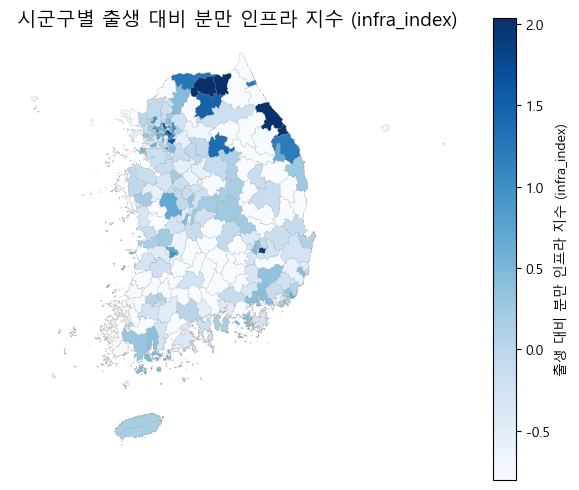

In [55]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

gdf_plot = gdf_merged.copy()
gdf_plot["infra_index"] = pd.to_numeric(gdf_plot["infra_index"], errors="coerce")

# 1) 색 스케일: 극단값 약간 잘라서 보기 좋게 (2%~98% 분위수)
vmin = gdf_plot["infra_index"].quantile(0.02)
vmax = gdf_plot["infra_index"].quantile(0.98)

fig, ax = plt.subplots(figsize=(6, 8))

gdf_plot.plot(
    column="infra_index",
    cmap="Blues",          # 낮을수록 연한 파랑, 높을수록 진한 파랑
    vmin=vmin,
    vmax=vmax,
    linewidth=0.1,
    edgecolor="gray",
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "출생 대비 분만 인프라 지수 (infra_index)",
        "shrink": 0.6,
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "데이터 없음",
    },
)

ax.set_title("시군구별 출생 대비 분만 인프라 지수 (infra_index)", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()


### 1. Blues 지도의 의미
```text
1. 지금 색( infra_index )이 말해주는 것

우리가 infra_index를 만들 때 했던 일은:
각 시군구에 대해
산부인과 수 / (출생수 / 1,000) → obgyn_per_1000
산후조리원 수 / (출생수 / 1,000) → ppcenter_per_1000
병실 수 / (출생수 / 1,000) → ppbeds_per_1000
이 세 개를 각각 표준화(z-score)한 뒤 평균 → infra_index
그래서 지도에서 색이 옅다/진하다는 건:
“이 시군구는
출생 1,000명당 산부인과·조리원·병실 수가
전국 평균보다 얼마나 낮거나 높은지”
를 보여주는 겁니다.

즉, 출생 규모(인구)를 분모에 넣고 계산했기 때문에,
단순히 “시설 수가 적다”가 아니라:
“태어나는 아기 수에 비해
인프라가 상대적으로 적다(= 색 옅다) / 많다(= 색 진하다)”
라는 의미를 어느 정도는 담고 있습니다.

2. 그러나 “인구가 적은 걸 완벽히 반영했다”라고까지 보긴 어려운 이유
몇 가지 한계가 있어요.

- 출생수가 너무 작은 시군구

출생이 30명, 40명 이런 곳은
분모가 작아서 “1개 늘고 줄고”에 지표가 요동칩니다.

그래서 색은 “비율상 부족/풍부”를 보여주지만,
**정책 우선순위(얼마나 많은 아기가 영향을 받는지)**까지 한 번에 표현해 주진 못합니다.

- infra_index는 “전국 평균 대비 상대 위치”

값이 -0.8이면 “전국 평균보다 0.8 표준편차만큼 낮다”는 뜻이지,
“절대적으로 이 정도면 위험하다” 같은 절대 기준은 아닙니다.

그래서 지금 Blues 지도의 색은:
“출생 대비 인프라가 전국 평균과 비교해 상대적으로 얼마나 부족/풍부한지”
(인구 규모를 어느 정도 감안한 ‘비율’의 개념)
까지만 담고 있다고 이해하시면 됩니다.

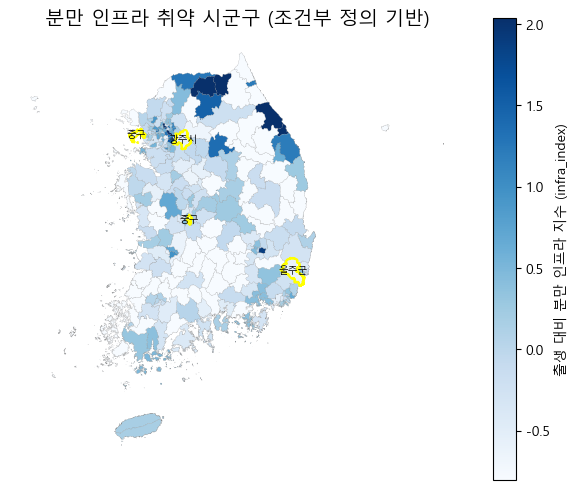

In [63]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 0) 복사 후 infra_index 숫자형으로
gdf_plot = gdf_merged.copy()
gdf_plot["infra_index"] = pd.to_numeric(gdf_plot["infra_index"], errors="coerce")

# 1) 색 스케일: 극단값 약간 잘라서 보기 좋게 (2%~98% 분위수)
vmin = gdf_plot["infra_index"].quantile(0.02)
vmax = gdf_plot["infra_index"].quantile(0.98)

fig, ax = plt.subplots(figsize=(6, 8))

# 2) 배경: infra_index 색 채우기 (Blues + 같은 vmin/vmax + 같은 legend 옵션)
gdf_plot.plot(
    column="infra_index",
    cmap="Blues",          # 낮을수록 연한 파랑, 높을수록 진한 파랑
    vmin=vmin,
    vmax=vmax,
    linewidth=0.1,
    edgecolor="gray",
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "출생 대비 분만 인프라 지수 (infra_index)",
        "shrink": 0.6,
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "데이터 없음",
    },
)

# 3) 취약 시군구만 테두리 두껍게 표시
vul = gdf_plot[gdf_plot["is_vulnerable"] == True]

vul.boundary.plot(
    ax=ax,
    linewidth=1.5,
    edgecolor="yellow",
)

# (선택) 취약 시군구 이름 라벨 찍기
for idx, row in vul.iterrows():
    if row["geometry"].centroid.is_empty:
        continue
    x = row["geometry"].centroid.x
    y = row["geometry"].centroid.y
    label = f'{row["시군구"]}'
    ax.text(x, y, label, fontsize=7, ha="center", va="center", color="black")

ax.set_title("분만 인프라 취약 시군구 (조건부 정의 기반)", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()


### 2. 분만 인프라 취약 시군구 지도의 의미
```text
우리가 따로 is_vulnerable 레이어를 얹은 이유

이 한계를 보완하려고, 취약 시군구는 별도의 조건을 걸었죠.

infra_index 하위 25% → 출생 대비 인프라 비율이 낮은 곳
출생등록수 ≥ 전국 중앙값 → 출생(수요)이 적지 않은 곳
회귀 잔차 하위 20% → is_metro와 출생규모를 감안해도
기대보다 특히 부족한 곳

그래서:
지도 배경 색(Blues)
→ “출생 대비 인프라 비율이 전국 평균 대비 어느 정도인가”

검은 테두리(취약 시군구)
→ “그 중에서도 출생도 적지 않고,
‘대도시 여부 + 출생 규모’를 감안한 기대치보다
특히 부족한 구조적 취약 지역”

으로 역할을 나눠 둔 상태라고 보시면 됩니다.